In [ ]:
import pandas as pd
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, StratifiedKFold

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score
)


"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data_train = pd.read_csv("../../../dataset/Spotify_train_preprocesado_clasificacion.csv")

data_test = pd.read_csv("../../../dataset/Spotify_test_preprocesado_clasificacion.csv")

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento: ")
display(df_train.head())


print("Dataset de pruebas: ")
display(df_test.head())

Dataset de entrenamiento: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


Dataset de pruebas: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [3]:
X_train = df_train.drop(columns=["popularity_category"])
y_train = df_train["popularity_category"]

X_test = df_test.drop(columns=["popularity_category"])
y_test = df_test["popularity_category"]

In [7]:
# Configuración de validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo SVM lineal
svm_model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

# Métricas
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro"
}

# Validación cruzada
scores_svm = cross_validate(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Resumen de resultados
resultados_svm = {
    metrica: scores_svm[f"test_{metrica}"].mean()
    for metrica in scoring
}

print("Resultados de SVM (LinearSVC):")

for metrica, valor in resultados_svm.items():
    print(f"{metrica}: {valor:.4f}")

print("\nDesviación estándar:")

for metrica in scoring:
    desviacion = scores_svm[f"test_{metrica}"].std()
    print(f"{metrica}: {desviacion:.4f}")

Resultados de SVM (LinearSVC):
accuracy: 0.3582
balanced_accuracy: 0.3582
precision_weighted: 0.3472
recall_weighted: 0.3582
f1_weighted: 0.3369
f1_macro: 0.3369

Desviación estándar:
accuracy: 0.0021
balanced_accuracy: 0.0021
precision_weighted: 0.0029
recall_weighted: 0.0021
f1_weighted: 0.0025
f1_macro: 0.0025


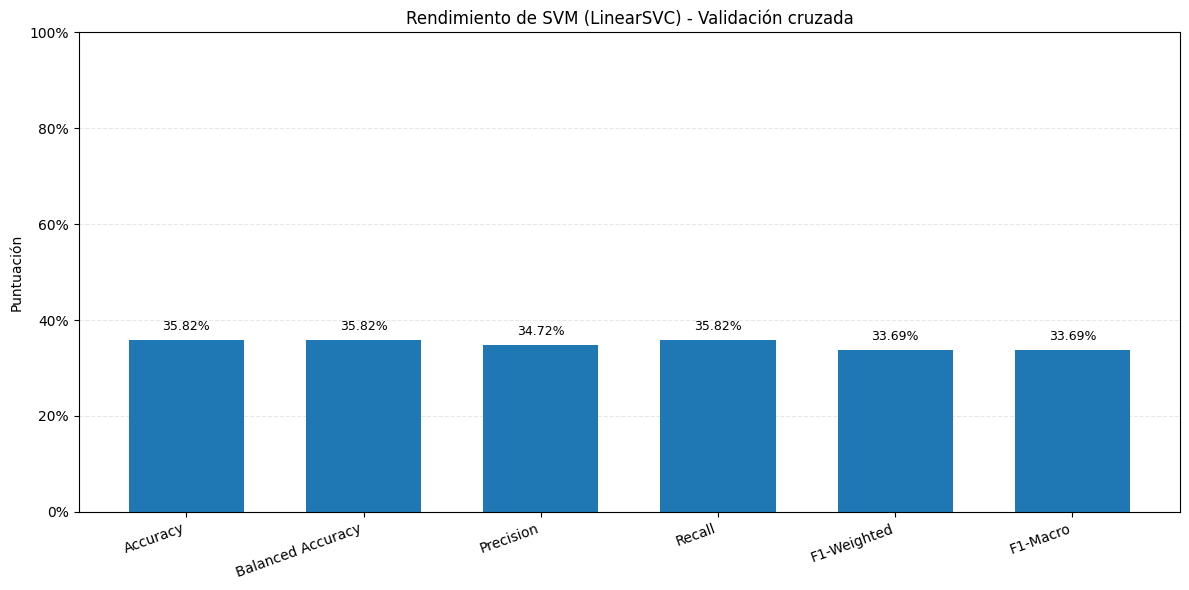

In [8]:
metricas_grafico = {
    "Accuracy": resultados_svm["accuracy"],
    "Balanced Accuracy": resultados_svm["balanced_accuracy"],
    "Precision": resultados_svm["precision_weighted"],
    "Recall": resultados_svm["recall_weighted"],
    "F1-Weighted": resultados_svm["f1_weighted"],
    "F1-Macro": resultados_svm["f1_macro"]
}

fig, ax = plt.subplots(figsize=(12, 6))

nombres = list(metricas_grafico.keys())
valores = list(metricas_grafico.values())

barras = ax.bar(nombres, valores, width=0.65)

for barra, valor in zip(barras, valores):
    ax.annotate(
        f"{valor:.2%}",
        xy=(barra.get_x() + barra.get_width() / 2,
            barra.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Rendimiento de SVM (LinearSVC) - Validación cruzada")
ax.set_ylabel("Puntuación")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Entrenar el modelo definitivo
svm_model.fit(X_train, y_train)

# Predicciones sobre datos no vistos
y_pred_svm = svm_model.predict(X_test)

In [13]:
# Métricas finales
print("Resultados de SVM en el conjunto de prueba:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

print(
    "Balanced Accuracy:",
    f"{balanced_accuracy_score(y_test, y_pred_svm):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}"
)

print(
    "Recall:",
    f"{recall_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}"
)

print(
    "F1-Weighted:",
    f"{f1_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}"
)

print(
    "F1-Macro:",
    f"{f1_score(y_test, y_pred_svm, average='macro', zero_division=0):.4f}"
)

print("\nReporte de clasificación de SVM:")
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

Resultados de SVM en el conjunto de prueba:
Accuracy: 0.2831
Balanced Accuracy: 0.3507
Precision: 0.3821
Recall: 0.2831
F1-Weighted: 0.3145
F1-Macro: 0.2449

Reporte de clasificación de SVM:
              precision    recall  f1-score   support

           0       0.40      0.25      0.31      6742
           1       0.41      0.41      0.41      6615
           2       0.43      0.21      0.29      6615
           3       0.17      0.18      0.18      2522
           4       0.02      0.70      0.04       191

    accuracy                           0.28     22685
   macro avg       0.29      0.35      0.24     22685
weighted avg       0.38      0.28      0.31     22685



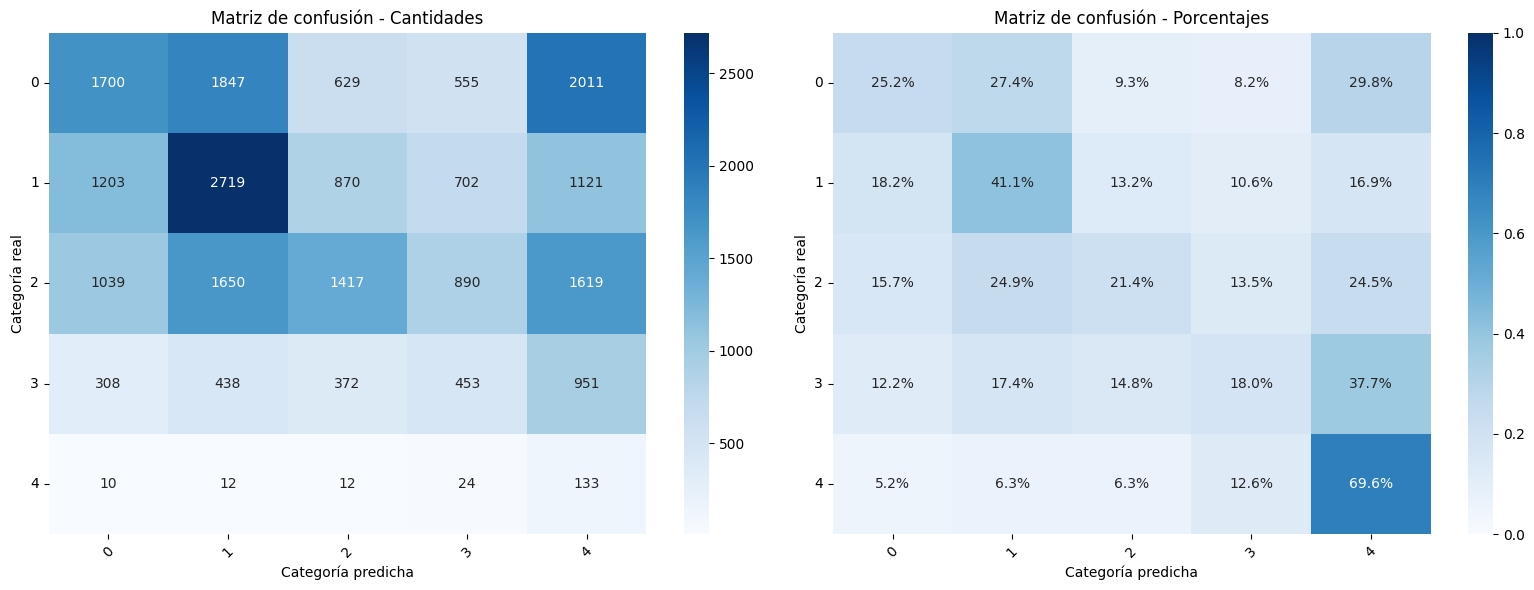

In [14]:
etiquetas = svm_model.classes_

matriz = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=etiquetas
)

matriz_normalizada = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=etiquetas,
    normalize="true"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=axes[0]
)

axes[0].set_title("Matriz de confusión - Cantidades")
axes[0].set_xlabel("Categoría predicha")
axes[0].set_ylabel("Categoría real")

sns.heatmap(
    matriz_normalizada,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=axes[1]
)

axes[1].set_title("Matriz de confusión - Porcentajes")
axes[1].set_xlabel("Categoría predicha")
axes[1].set_ylabel("Categoría real")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()